## Experimentation with active contours

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from kraken.blla import segment
from kraken.lib.vgsl import TorchVGSLModel
from skimage.segmentation import active_contour

In [2]:
# Loading the image and segmenting the images and 

import kraken

image_path = Path("../data/manuscripts/pages/Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_6.jpeg")

image = Image.open(image_path).convert("RGB")

model_path = Path(kraken.__file__).parent / "blla.mlmodel"
model = TorchVGSLModel.load_model(str(model_path))
segmented = segment(im=image, model=model, device="cpu")

boundaries = [line.boundary for line in segmented.lines if line.boundary and len(line.boundary) >= 3]
print(f"{image_path.name}: {image.size[0]}×{image.size[1]} px, {len(boundaries)} lines")

/Users/krishuagarwal/Desktop/Programming/python/greekOCR/annote/backend/.venv/lib/python3.11/site-packages/coremltools/models/model.py:628: RuntimeWarning: You will not be able to run predict() on this Core ML model. Underlying exception message was: Error compiling model: "compiler error: Error reading protobuf spec. validator error: Input MLMultiArray to neural networks must have dimension 1 (vector) or 3 (image-like arrays).".
  _warnings.warn(


Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_6.jpeg: 1447×1054 px, 34 lines


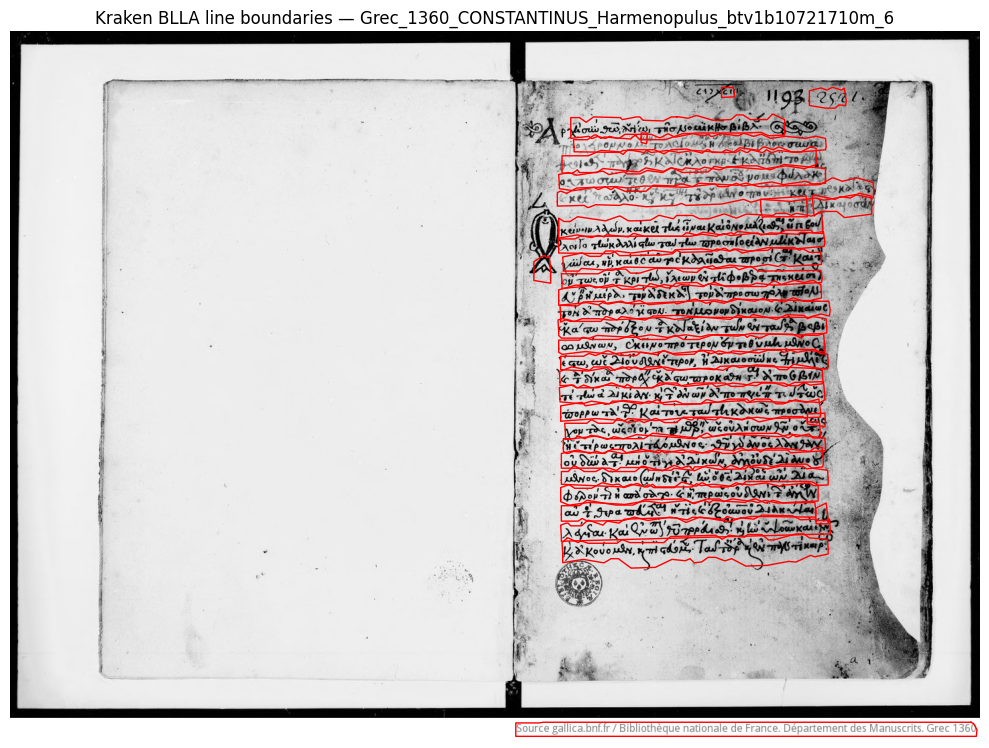

In [3]:
# Viewing the segments.

fig, ax = plt.subplots(figsize=(10, 14))
ax.imshow(image)

for boundary in boundaries:
    pts = np.array(boundary, dtype=float)
    closed = np.vstack([pts, pts[0]])
    ax.plot(closed[:, 0], closed[:, 1], "r-", linewidth=1)

ax.set_title(f"Kraken BLLA line boundaries — {image_path.stem}")
ax.axis("off")

plt.tight_layout()
plt.show()

### Zoom: one segment and its neighbours (±1)

Pick a 1-based line number (e.g. 11 → shows lines 10, 11, 12).

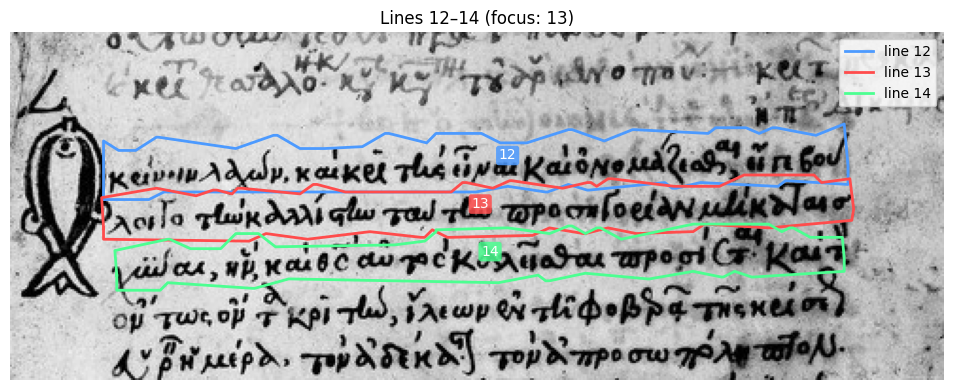

In [4]:
FOCUS_LINE = 13  # 1-based line number
PAD_PX = 48

line_numbers = [FOCUS_LINE - 1, FOCUS_LINE, FOCUS_LINE + 1]
indices = [n - 1 for n in line_numbers]
if any(i < 0 or i >= len(boundaries) for i in indices):
    raise IndexError(
        f"Lines {line_numbers} out of range for {len(boundaries)} detected lines"
    )

selected = [(n, np.array(boundaries[i], dtype=float)) for n, i in zip(line_numbers, indices)]
all_pts = np.vstack([pts for _, pts in selected])

x0 = max(int(np.floor(all_pts[:, 0].min())) - PAD_PX, 0)
y0 = max(int(np.floor(all_pts[:, 1].min())) - PAD_PX, 0)
x1 = min(int(np.ceil(all_pts[:, 0].max())) + PAD_PX, image.width)
y1 = min(int(np.ceil(all_pts[:, 1].max())) + PAD_PX, image.height)

crop = image.crop((x0, y0, x1, y1))
colors = {FOCUS_LINE - 1: "#4c9aff", FOCUS_LINE: "#ff4c4c", FOCUS_LINE + 1: "#4cff91"}

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(crop)
for line_no, pts in selected:
    shifted = pts - np.array([x0, y0])
    closed = np.vstack([shifted, shifted[0]])
    color = colors[line_no]
    ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=2, label=f"line {line_no}")
    centroid = shifted.mean(axis=0)
    ax.text(
        centroid[0],
        centroid[1],
        str(line_no),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc=color, ec="none", alpha=0.85),
    )

ax.set_title(f"Lines {line_numbers[0]}–{line_numbers[-1]} (focus: {FOCUS_LINE})")
ax.legend(loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.show()

### Neighbour-guided crop (margin + union)

Expand the ±1 neighbour polygons outward by a few pixels, union them to define the crop region, then show only the focus line boundary.

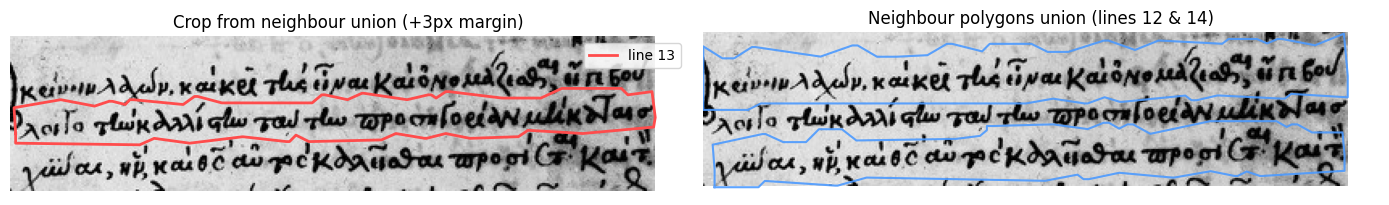

In [5]:
from shapely.geometry import Polygon
from shapely.ops import unary_union

FOCUS_LINE = 13  # 1-based line number
NEIGHBOUR_MARGIN_PX = 3


def polygon_with_margin(points: np.ndarray, margin_px: float) -> Polygon:
    poly = Polygon(points)

    if not poly.is_valid:
        poly = poly.buffer(0)

    return poly.buffer(margin_px, join_style=2)  # mitre joins keep corner vertices sharp


focus_idx = FOCUS_LINE - 1
neighbour_numbers = [FOCUS_LINE - 1, FOCUS_LINE + 1]
neighbour_indices = [n - 1 for n in neighbour_numbers]
all_indices = [focus_idx, *neighbour_indices]

if any(i < 0 or i >= len(boundaries) for i in all_indices):
    raise IndexError(
        f"Lines {[FOCUS_LINE, *neighbour_numbers]} out of range for {len(boundaries)} detected lines"
    )

focus_pts = np.array(boundaries[focus_idx], dtype=float)
neighbour_polys = [
    polygon_with_margin(np.array(boundaries[i], dtype=float), NEIGHBOUR_MARGIN_PX)
    for i in neighbour_indices
]
combined_neighbours = unary_union(neighbour_polys)

# Find the maximum and minimum of the combined polygon to get the coordinates of the crop. 
crop_region = unary_union([Polygon(focus_pts), combined_neighbours])
minx, miny, maxx, maxy = crop_region.bounds

x0 = max(int(np.floor(minx)), 0)
y0 = max(int(np.floor(miny)), 0)
x1 = min(int(np.ceil(maxx)), image.width)
y1 = min(int(np.ceil(maxy)), image.height)

crop = image.crop((x0, y0, x1, y1))
focus_shifted = focus_pts - np.array([x0, y0])
focus_closed = np.vstack([focus_shifted, focus_shifted[0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(crop)
axes[0].plot(focus_closed[:, 0], focus_closed[:, 1], color="#ff4c4c", linewidth=2, label=f"line {FOCUS_LINE}")
axes[0].set_title(f"Crop from neighbour union (+{NEIGHBOUR_MARGIN_PX}px margin)")
axes[0].legend(loc="upper right")
axes[0].axis("off")

# Debug view: neighbour union outline (not the focus line ink boundary).
axes[1].imshow(crop)
if combined_neighbours.geom_type == "Polygon":
    neighbour_parts = [combined_neighbours]
elif combined_neighbours.geom_type == "MultiPolygon":
    neighbour_parts = list(combined_neighbours.geoms)
else:
    neighbour_parts = []

for part in neighbour_parts:
    xs, ys = part.exterior.xy
    axes[1].plot(np.array(xs) - x0, np.array(ys) - y0, color="#4c9aff", linewidth=1.5, alpha=0.9)
    
axes[1].set_title(f"Neighbour polygons union (lines {neighbour_numbers[0]} & {neighbour_numbers[1]})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Nuances
Kraken stores each boundary as an ordered list of `[x, y]` page pixels (column, row).  
Edges run from vertex `i` → `(i + 1) % n`. scikit-image snakes use `(row, col)` = `(y, x)` instead.

We will have a lot of points on the boundary / sample it because without a good starting point the `snake` algorithm doesn't work. 

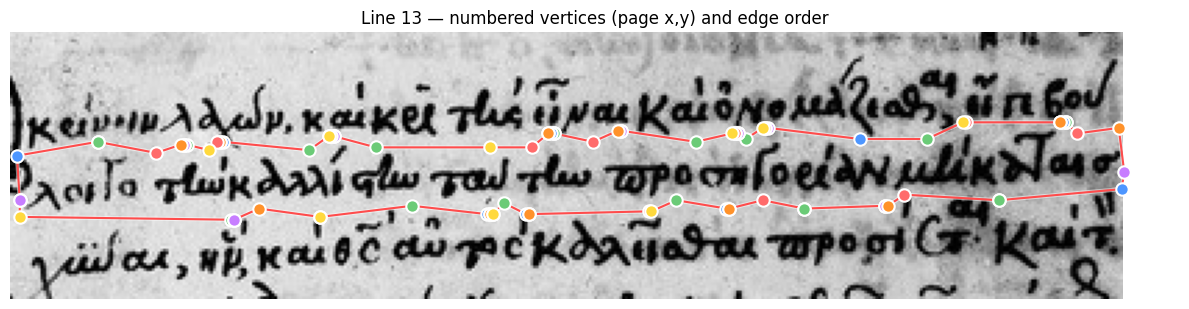

In [6]:
# Visualizing the kraken polygon - to add more points on the boundary. 

VERTEX_COLORS = ["#ff6b6b", "#ffd93d", "#6bcb77", "#4d96ff", "#c77dff", "#ff922b"]

focus_local = focus_pts - np.array([x0, y0])
n = len(focus_pts)

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(crop)

closed = np.vstack([focus_local, focus_local[0]])
ax.plot(closed[:, 0], closed[:, 1], color="#ffffff", linewidth=3, alpha=0.5, zorder=1)
ax.plot(closed[:, 0], closed[:, 1], color="#ff4c4c", linewidth=1.5, zorder=2)

for i in range(n):
    x, y = focus_local[i]
    color = VERTEX_COLORS[i % len(VERTEX_COLORS)]
    ax.scatter(x, y, s=80, c=color, edgecolors="white", linewidths=1.5, zorder=3)


ax.set_title(f"Line {FOCUS_LINE} — numbered vertices (page x,y) and edge order")
ax.axis("off")
plt.tight_layout()
plt.show()

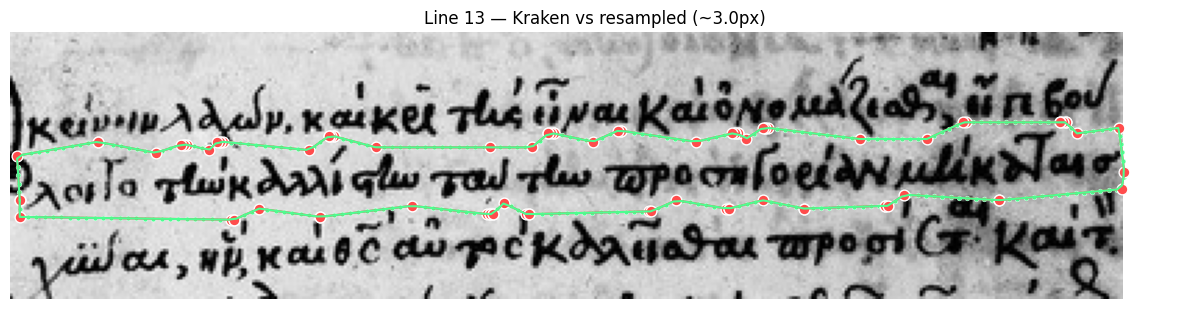

In [7]:
# Resample Kraken boundary for snake seeding (~SAMPLE_SPACING_PX apart).

SAMPLE_SPACING_PX = 3.0


def resample_closed_polygon(points: np.ndarray, spacing: float = SAMPLE_SPACING_PX) -> np.ndarray:
    if len(points) < 3:
        return points.astype(np.float64)

    closed = points if np.linalg.norm(points[0] - points[-1]) <= 1e-3 else np.vstack([points, points[:1]])
    seg = np.diff(closed, axis=0)
    cumulative = np.concatenate(([0.0], np.cumsum(np.hypot(seg[:, 0], seg[:, 1]))))

    if cumulative[-1] <= spacing:
        return points.astype(np.float64)

    targets = np.linspace(0, cumulative[-1], max(int(np.ceil(cumulative[-1] / spacing)), 12), endpoint=False)
    sampled, j = [], 1

    for t in targets:
        while j < len(cumulative) - 1 and cumulative[j] < t:
            j += 1

        seg_len = cumulative[j] - cumulative[j - 1]
        r = 0.0 if seg_len <= 1e-6 else (t - cumulative[j - 1]) / seg_len
        sampled.append(closed[j - 1] + r * (closed[j] - closed[j - 1]))

    return np.asarray(sampled, dtype=np.float64)


focus_resampled_local = resample_closed_polygon(focus_local)
focus_resampled_page = focus_resampled_local + [x0, y0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(crop)
for pts, color in [(focus_local, "#ff4c4c"), (focus_resampled_local, "#4cff91")]:
    loop = np.vstack([pts, pts[0]])
    ax.plot(loop[:, 0], loop[:, 1], color=color, lw=1.5)

ax.scatter(*focus_resampled_local.T, s=12, c="#4cff91", edgecolors="white", linewidths=0.3)
ax.scatter(*focus_local.T, s=60, c="#ff4c4c", edgecolors="white", linewidths=1)
ax.set_title(f"Line {FOCUS_LINE} — Kraken vs resampled (~{SAMPLE_SPACING_PX}px)")
ax.axis("off")

plt.tight_layout()
plt.show()

### Line 13 experiment — Kraken + Otsu + 4px + simplify

Run cells **2 → 7**, then tweak `MERGE_DIST_PX` / `SIMPLIFY_TOL_PX` below.


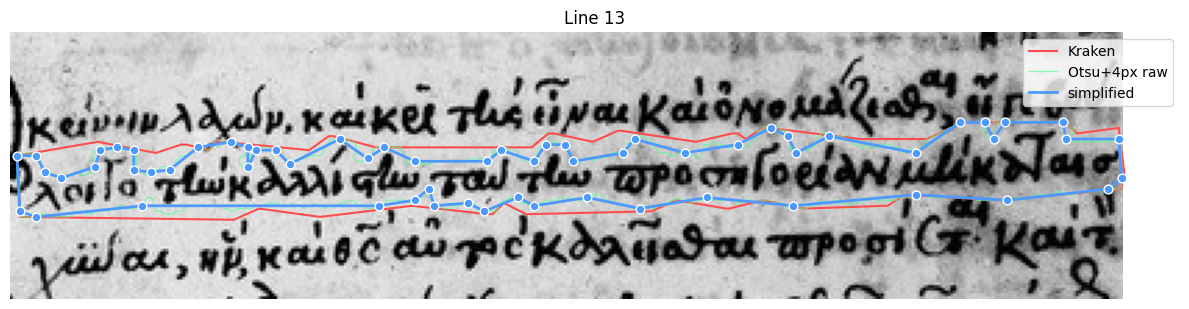

Kraken:     89 vertices
Otsu raw:   938 vertices
Simplified: 63 vertices


In [ ]:
# Line 13 — Kraken + Otsu + 4px + simplify (run cells 2, 7).

import cv2

FOCUS_LINE = 13
INK_OFFSET_PX = 4
MERGE_DIST_PX = 6.0      # drop dense consecutive vertices
SIMPLIFY_TOL_PX = 2.0    # Douglas–Peucker tolerance

focus_local = focus_pts - np.array([x0, y0])
gray = cv2.cvtColor(np.array(crop), cv2.COLOR_RGB2GRAY)
h, w = gray.shape


def local_mask(boundary_page):
    mask = np.zeros((h, w), np.uint8)
    pts = (np.asarray(boundary_page, dtype=float) - [x0, y0]).astype(np.int32)
    cv2.fillPoly(mask, [pts], 255)
    return mask


def otsu_ink(gray, region_mask):
    work = gray.copy()
    work[region_mask == 0] = 255
    _, ink = cv2.threshold(cv2.GaussianBlur(work, (3, 3), 0), 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return cv2.bitwise_and(ink, region_mask)


def dilated_band(ink, ceiling, margin_px):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(margin_px * 2 + 1), int(margin_px * 2 + 1)))
    return cv2.bitwise_and(cv2.dilate(ink, k), ceiling)


def band_contour(band):
    cnts, _ = cv2.findContours(band, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    return max(cnts, key=cv2.contourArea).reshape(-1, 2).astype(float)


def merge_close(points, min_distance=MERGE_DIST_PX):
    if len(points) < 2:
        return points
    pts = [list(p) for p in points]
    if len(pts) >= 2 and np.hypot(pts[0][0] - pts[-1][0], pts[0][1] - pts[-1][1]) <= min_distance:
        pts.pop()
    merged = [pts[0]]
    for p in pts[1:]:
        if np.hypot(p[0] - merged[-1][0], p[1] - merged[-1][1]) > min_distance:
            merged.append(p)
    if len(merged) >= 2 and np.hypot(merged[0][0] - merged[-1][0], merged[0][1] - merged[-1][1]) <= min_distance:
        merged.pop()
    return np.asarray(merged, float) if len(merged) >= 3 else points


def simplify_polygon(points, tolerance=SIMPLIFY_TOL_PX):
    if len(points) < 3:
        return points
    c = np.asarray(points, np.float32).reshape(-1, 1, 2)
    s = cv2.approxPolyDP(c, tolerance, True)
    return s.reshape(-1, 2).astype(float) if s is not None and len(s) >= 3 else points


ceiling = local_mask(boundaries[FOCUS_LINE - 1])
focus_ink = otsu_ink(gray, ceiling)
band = dilated_band(focus_ink, ceiling, INK_OFFSET_PX)
raw_local = band_contour(band)
simple_local = simplify_polygon(merge_close(raw_local)) if raw_local is not None else None

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(crop)
ax.plot(*np.vstack([focus_local, focus_local[0]]).T, color="#ff4c4c", lw=1.5, label="Kraken")
if raw_local is not None:
    ax.plot(raw_local[:, 0], raw_local[:, 1], color="#4cff91", lw=1, alpha=0.6, label=f"Otsu+{INK_OFFSET_PX}px raw")
if simple_local is not None:
    loop = np.vstack([simple_local, simple_local[0]])
    ax.plot(loop[:, 0], loop[:, 1], color="#4c9aff", lw=2, label="simplified")
    ax.scatter(simple_local[:, 0], simple_local[:, 1], s=40, c="#4c9aff", edgecolors="white", zorder=3)
ax.set_title(f"Line {FOCUS_LINE}")
ax.legend(loc="upper right") 
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Kraken:     {len(focus_local)} vertices")
print(f"Otsu raw:   {len(raw_local) if raw_local is not None else 0} vertices")
print(f"Simplified: {len(simple_local) if simple_local is not None else 0} vertices")


### Final comparison — grayscale Otsu vs Kraken `nlbin`

Same pipeline on the crop: **Kraken ceiling**, **ink + 3px**, optional inward snake.  
Left = grayscale + Otsu ink mask. Right = full page binarized with Kraken `nlbin`, then ink taken as dark pixels (no Otsu).

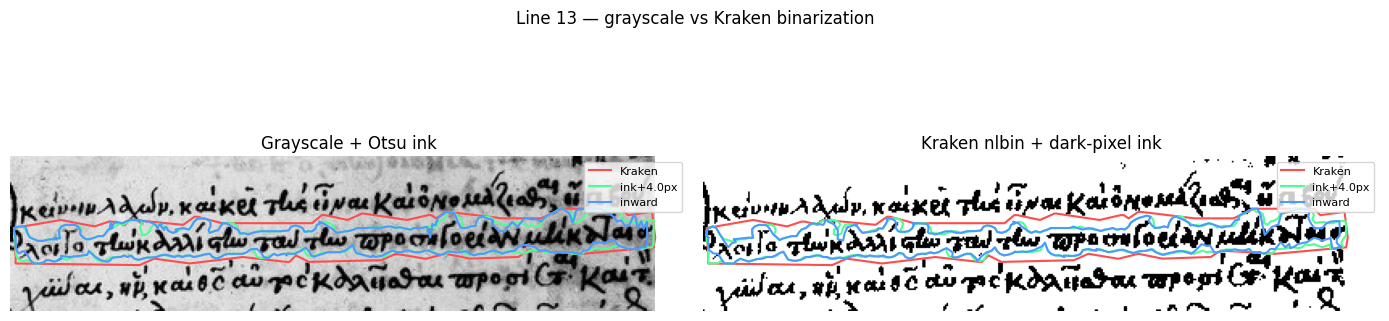

In [ ]:
# Run cells 7, 10, 12 first.

from kraken import binarization

page_bin = binarization.nlbin(image.convert("L"))
crop_bin = np.array(page_bin.crop((x0, y0, x1, y1)))


def ink_margin_from_binary(binarized_gray, ceiling, margin_px):
    """Ink = dark pixels on a Kraken-binarized image (skip Otsu)."""
    ink = ((binarized_gray < 128).astype(np.uint8)) * 255
    ink = cv2.bitwise_and(ink, ceiling)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (max(int(margin_px * 2) + 1, 3),) * 2)
    band = cv2.bitwise_and(cv2.dilate(ink, k, iterations=1), ceiling)
    contours, _ = cv2.findContours(band, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return focus_resampled_local
    contour = max(contours, key=cv2.contourArea).reshape(-1, 2).astype(np.float64)
    return resample_closed_polygon(contour, spacing=SAMPLE_SPACING_PX)


ink_margin_bin_local = ink_margin_from_binary(crop_bin, ceiling, INK_OFFSET_PX)
edges_bin = np.where(ceiling, make_edges(crop_bin, BLUR_SIGMA), 0.0)
inward_bin_local = evolve_inward(edges_bin, ink_margin_bin_local, ceiling)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(crop)
axes[0].set_title("Grayscale + Otsu ink")
for pts, color, label in [
    (focus_local, "#ff4c4c", "Kraken"),
    (ink_margin_local, "#4cff91", f"ink+{INK_OFFSET_PX}px"),
    (contour_inward_local, "#4c9aff", "inward"),
]:
    axes[0].plot(*np.vstack([pts, pts[0]]).T, color=color, lw=1.5, label=label)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].axis("off")

axes[1].imshow(crop_bin, cmap="gray")
axes[1].set_title("Kraken nlbin + dark-pixel ink")
for pts, color, label in [
    (focus_local, "#ff4c4c", "Kraken"),
    (ink_margin_bin_local, "#4cff91", f"ink+{INK_OFFSET_PX}px"),
    (inward_bin_local, "#4c9aff", "inward"),
]:
    axes[1].plot(*np.vstack([pts, pts[0]]).T, color=color, lw=1.5, label=label)
axes[1].legend(loc="upper right", fontsize=8)
axes[1].axis("off")

fig.suptitle(f"Line {FOCUS_LINE} — grayscale vs Kraken binarization", y=1.02)
plt.tight_layout()
plt.show()

Not much benefits I would say of `binarization`

#### We found a good thing

In CV there is a thing named as `otsu` threshold, it is very strong in bimodal distribution like ours so we can use that to get the finer segments inside kraken. 

### Whole page — Kraken → per-segment Otsu → ink + margin

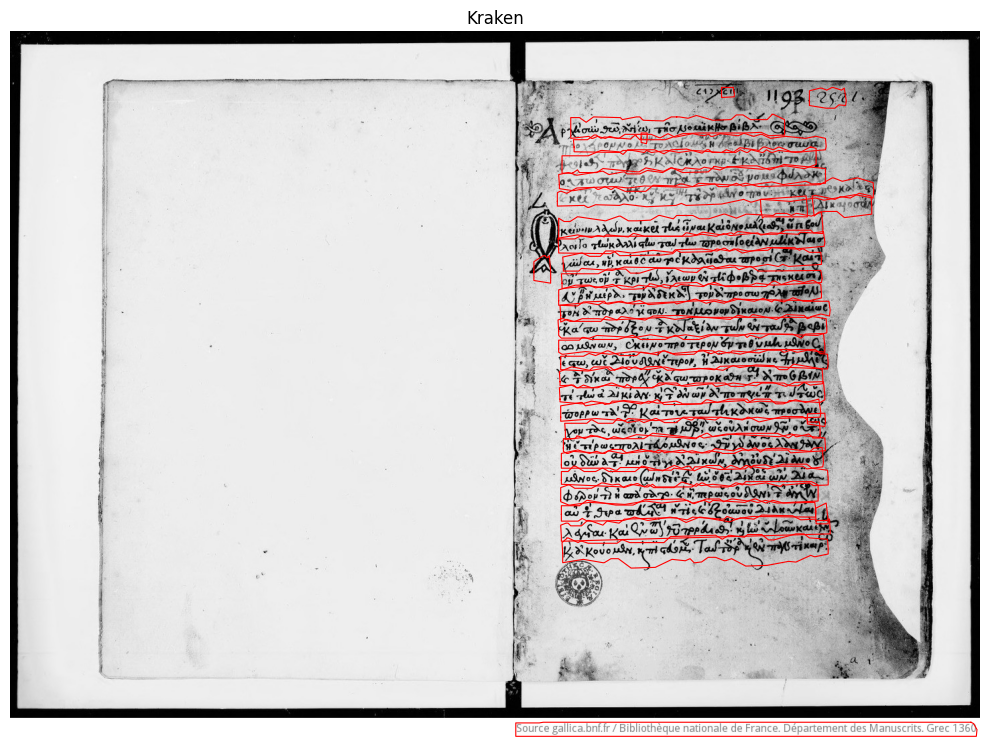

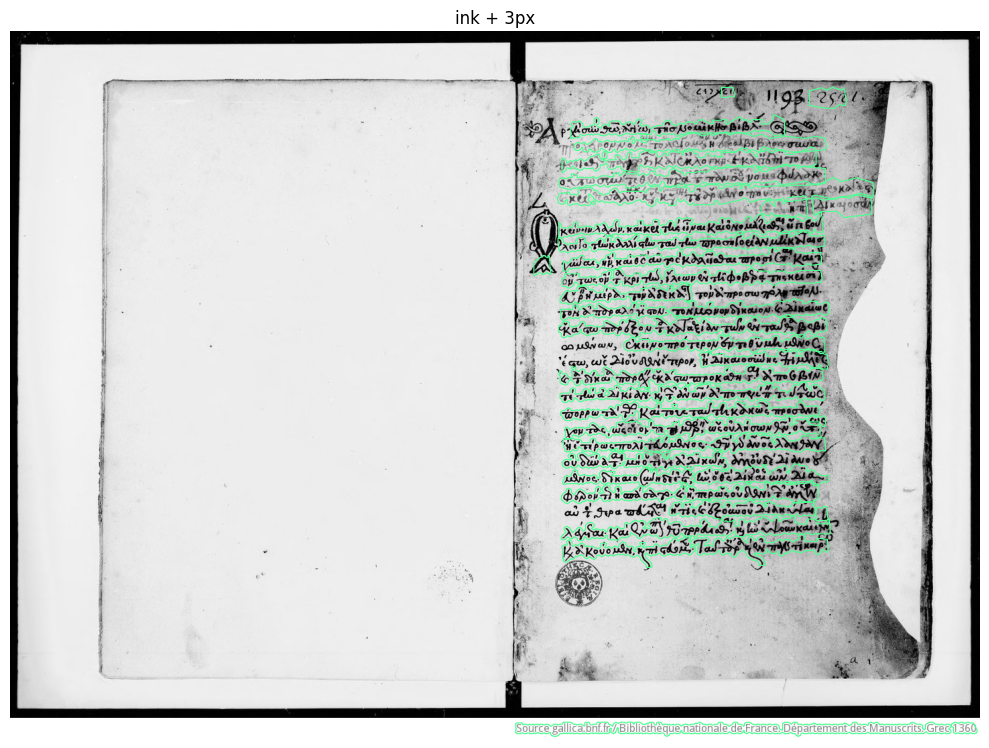

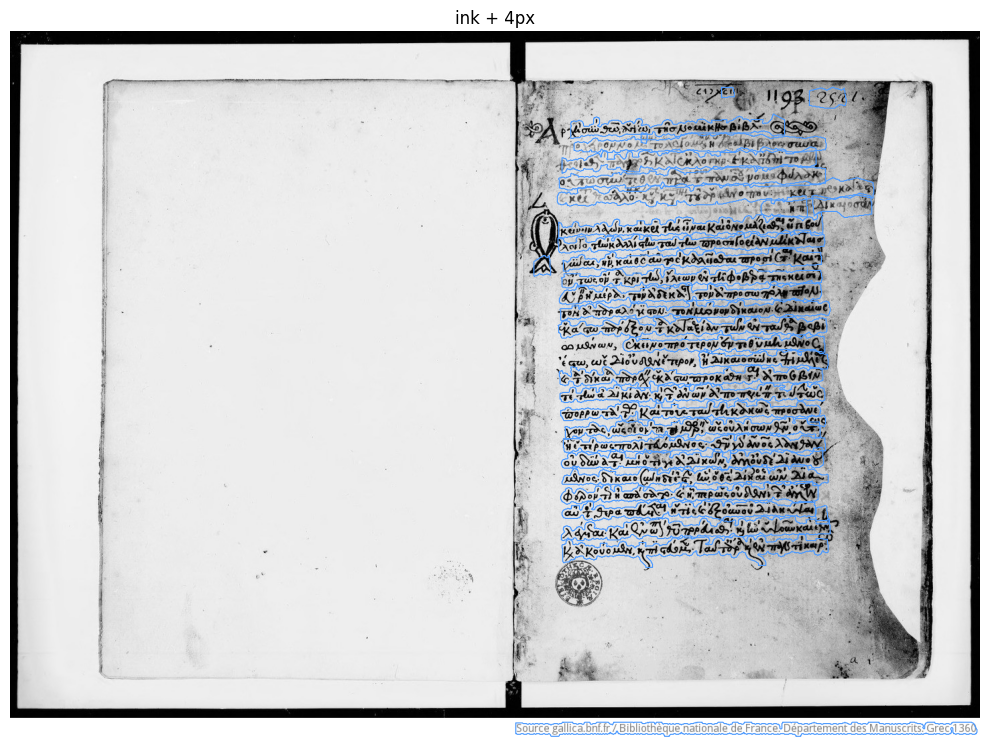

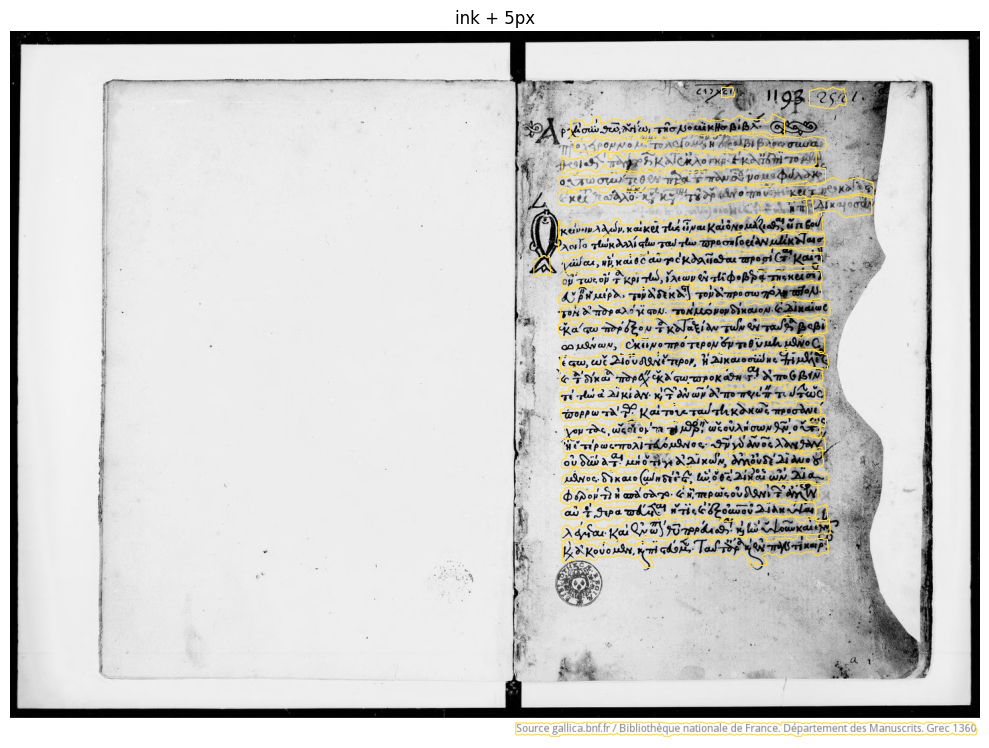

In [ ]:
# Run cell 2 first.

import cv2

MARGINS_PX = [3, 4, 5]
gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
h, w = gray.shape


def segment_contour(boundary, margin_px):
    mask = np.zeros((h, w), np.uint8)
    cv2.fillPoly(mask, [np.array(boundary, dtype=np.int32)], 255)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    y0, y1 = max(ys.min() - 2, 0), min(ys.max() + 3, h)
    x0, x1 = max(xs.min() - 2, 0), min(xs.max() + 3, w)
    crop = gray[y0:y1, x0:x1].copy()
    m = mask[y0:y1, x0:x1]
    crop[m == 0] = 255
    _, ink = cv2.threshold(cv2.GaussianBlur(crop, (3, 3), 0), 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(margin_px * 2) + 1,) * 2)
    band = cv2.bitwise_and(cv2.dilate(cv2.bitwise_and(ink, m), k), m)
    cnts, _ = cv2.findContours(band, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea).reshape(-1, 2).astype(float)
    c[:, 0] += x0
    c[:, 1] += y0
    return c


refined = {m: [segment_contour(b, m) for b in boundaries] for m in MARGINS_PX}

fig, ax = plt.subplots(figsize=(10, 14))
ax.imshow(image)
for b in boundaries:
    p = np.array(b, float)
    ax.plot(*np.vstack([p, p[0]]).T, "r-", lw=0.8)
ax.set_title("Kraken")
ax.axis("off")
plt.tight_layout()
plt.show()

for m, color in zip(MARGINS_PX, ["#4cff91", "#4c9aff", "#ffd93d"]):
    fig, ax = plt.subplots(figsize=(10, 14))
    ax.imshow(image)
    for c in refined[m]:
        if c is not None:
            ax.plot(c[:, 0], c[:, 1], color=color, lw=0.8)
    ax.set_title(f"ink + {m}px")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


Nope! Binarization doesn't work with **OTSU**

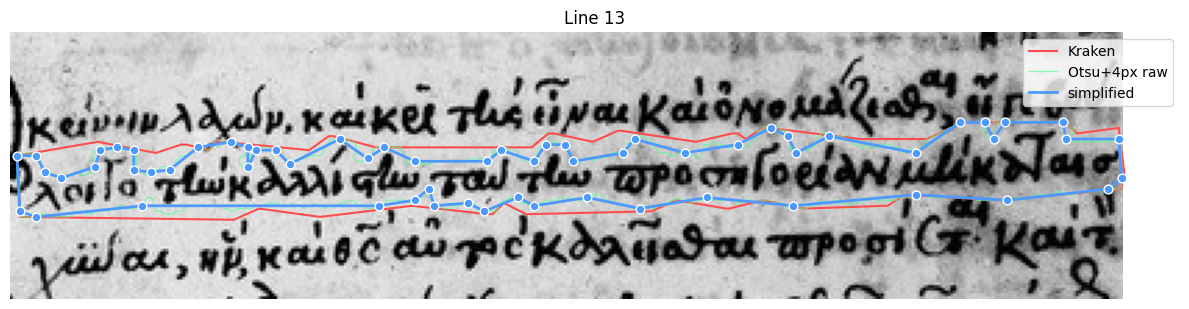

Kraken:     89 vertices
Otsu raw:   938 vertices
Simplified: 63 vertices


In [13]:
# Line 13 — Kraken + Otsu + 4px + simplify (run cells 2, 7).

import cv2

FOCUS_LINE = 13
INK_OFFSET_PX = 4
MERGE_DIST_PX = 6.0      # drop dense consecutive vertices
SIMPLIFY_TOL_PX = 2.0    # Douglas–Peucker tolerance

focus_local = focus_pts - np.array([x0, y0])
gray = cv2.cvtColor(np.array(crop), cv2.COLOR_RGB2GRAY)
h, w = gray.shape


def local_mask(boundary_page):
    mask = np.zeros((h, w), np.uint8)
    pts = (np.asarray(boundary_page, dtype=float) - [x0, y0]).astype(np.int32)
    cv2.fillPoly(mask, [pts], 255)
    return mask


def otsu_ink(gray, region_mask):
    work = gray.copy()
    work[region_mask == 0] = 255
    _, ink = cv2.threshold(cv2.GaussianBlur(work, (3, 3), 0), 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return cv2.bitwise_and(ink, region_mask)


def dilated_band(ink, ceiling, margin_px):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (int(margin_px * 2 + 1), int(margin_px * 2 + 1)))
    return cv2.bitwise_and(cv2.dilate(ink, k), ceiling)


def band_contour(band):
    cnts, _ = cv2.findContours(band, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return None
    return max(cnts, key=cv2.contourArea).reshape(-1, 2).astype(float)


def merge_close(points, min_distance=MERGE_DIST_PX):
    if len(points) < 2:
        return points
    pts = [list(p) for p in points]
    if len(pts) >= 2 and np.hypot(pts[0][0] - pts[-1][0], pts[0][1] - pts[-1][1]) <= min_distance:
        pts.pop()
    merged = [pts[0]]
    for p in pts[1:]:
        if np.hypot(p[0] - merged[-1][0], p[1] - merged[-1][1]) > min_distance:
            merged.append(p)
    if len(merged) >= 2 and np.hypot(merged[0][0] - merged[-1][0], merged[0][1] - merged[-1][1]) <= min_distance:
        merged.pop()
    return np.asarray(merged, float) if len(merged) >= 3 else points


def simplify_polygon(points, tolerance=SIMPLIFY_TOL_PX):
    if len(points) < 3:
        return points
    c = np.asarray(points, np.float32).reshape(-1, 1, 2)
    s = cv2.approxPolyDP(c, tolerance, True)
    return s.reshape(-1, 2).astype(float) if s is not None and len(s) >= 3 else points


ceiling = local_mask(boundaries[FOCUS_LINE - 1])
focus_ink = otsu_ink(gray, ceiling)
band = dilated_band(focus_ink, ceiling, INK_OFFSET_PX)
raw_local = band_contour(band)
simple_local = simplify_polygon(merge_close(raw_local)) if raw_local is not None else None

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(crop)
ax.plot(*np.vstack([focus_local, focus_local[0]]).T, color="#ff4c4c", lw=1.5, label="Kraken")
if raw_local is not None:
    ax.plot(raw_local[:, 0], raw_local[:, 1], color="#4cff91", lw=1, alpha=0.6, label=f"Otsu+{INK_OFFSET_PX}px raw")
if simple_local is not None:
    loop = np.vstack([simple_local, simple_local[0]])
    ax.plot(loop[:, 0], loop[:, 1], color="#4c9aff", lw=2, label="simplified")
    ax.scatter(simple_local[:, 0], simple_local[:, 1], s=40, c="#4c9aff", edgecolors="white", zorder=3)
ax.set_title(f"Line {FOCUS_LINE}")
ax.legend(loc="upper right") 
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Kraken:     {len(focus_local)} vertices")
print(f"Otsu raw:   {len(raw_local) if raw_local is not None else 0} vertices")
print(f"Simplified: {len(simple_local) if simple_local is not None else 0} vertices")
